# 01. Data Exploration

This notebook takes a first look at the raw dataset: how many patients there are, how much data is missing, and what the Kaplan-Meier survival curves look like for the two outcomes we care about (hepatic event and death). It then runs `build_patient_features()` once on the raw train and test data and writes the result to `liverrisk/data/processed/` using `save_features()` and `save_test_features()`.

Every other notebook, along with `scripts/train.py`, reads directly from `data/processed/` and never calls `build_patient_features()` again. You only need to rerun this notebook if you want to regenerate the engineered features from scratch.

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "liverrisk" / "features.py").exists():
            return p
    raise RuntimeError("Could not locate repo root (liverrisk/features.py not found)")


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sksurv.nonparametric import kaplan_meier_estimator

from liverrisk.features import (
    build_patient_features,
    prepare_survival_target,
    save_features,
    save_test_features,
    save_test_ids,
)

RAW_DIR = REPO_ROOT / "liverrisk" / "data" / "raw"
PROCESSED_DIR = REPO_ROOT / "liverrisk" / "data" / "processed"

TRAIN_PATH = RAW_DIR / "train.csv"
TEST_PATH = RAW_DIR / "test.csv"

## Load raw data

Reads the raw `train.csv` and `test.csv` files into pandas DataFrames so we can start exploring them.

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)
train_df.head()

train shape: (1253, 287)
test shape : (423, 284)


,patient_id_anon,gender,T2DM,Hypertension,Dyslipidaemia,bariatric_surgery,bariatric_surgery_age,Age_v1,Age_v2,Age_v3,...,fibs_stiffness_med_BM_1_v17,fibs_stiffness_med_BM_1_v18,fibs_stiffness_med_BM_1_v19,fibs_stiffness_med_BM_1_v20,fibs_stiffness_med_BM_1_v21,fibs_stiffness_med_BM_1_v22,evenements_hepatiques_majeurs,evenements_hepatiques_age_occur,death,death_age_occur
0,8MDD4V30T9NT,1,1.0,1.0,1.0,0.0,NaN,40.0,43.0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.0,NaN
1,3W5UZBIKCIDK,2,0.0,0.0,0.0,0.0,NaN,62.0,62.0,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.0,NaN
2,9XUY41IBLJH7,1,0.0,0.0,1.0,0.0,NaN,48.0,51.0,53.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.0,NaN
3,5LXO6QJIUJV6,1,1.0,1.0,1.0,0.0,NaN,55.0,56.0,58.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,67.0,1.0,72.0
4,1T2TALA753LC,1,0.0,0.0,0.0,0.0,NaN,45.0,48.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0.0,NaN


## Event rates

Counts how many patients experienced each outcome in the training set. Both endpoints are heavily censored, with only 47 hepatic events and 76 deaths among 1253 patients.

In [4]:
hep_events = (train_df["evenements_hepatiques_majeurs"] == 1).sum()
death_events = (train_df["death"] == 1).sum()

print(f"hepatic events: {hep_events} / {len(train_df)} ({hep_events / len(train_df):.3%})")
print(f"death events  : {death_events} / {len(train_df)} ({death_events / len(train_df):.3%})")

hepatic events: 47 / 1253 (3.751%)
death events  : 76 / 1253 (6.065%)


## Missingness

Plots the 20 columns with the highest fraction of missing values in the raw training table, giving a quick sense of which variables are the sparsest before any imputation happens.

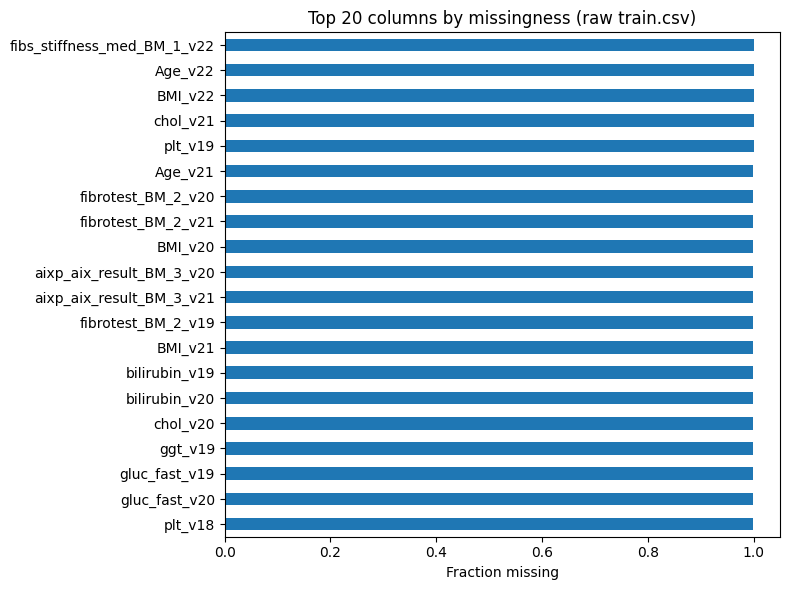

In [5]:
missing_frac = train_df.isna().mean().sort_values(ascending=False)
top_missing = missing_frac.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top_missing.iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("Fraction missing")
ax.set_title("Top 20 columns by missingness (raw train.csv)")
plt.tight_layout()
plt.show()

## Kaplan-Meier curves

Builds survival curves for each endpoint using the same `prepare_survival_target()` function used during model training, so the risk sets shown here match exactly what the models are trained on.

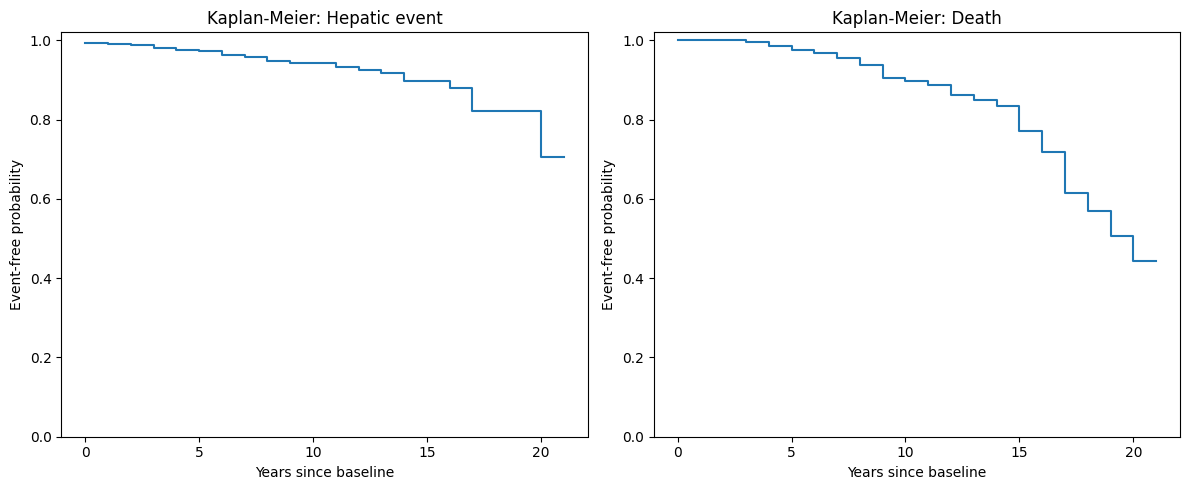

In [6]:
hep_df, y_hep, hep_event, hep_time = prepare_survival_target(train_df, "hepatic")
death_df, y_death, death_event, death_time = prepare_survival_target(train_df, "death")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, event, time) in zip(
    axes,
    [("Hepatic event", hep_event, hep_time), ("Death", death_event, death_time)],
):
    km_time, km_prob = kaplan_meier_estimator(event, time)
    ax.step(km_time, km_prob, where="post")
    ax.set_title(f"Kaplan-Meier: {label}")
    ax.set_xlabel("Years since baseline")
    ax.set_ylabel("Event-free probability")
    ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

## Build patient features

Runs `build_patient_features()` once on the training and test data to turn the raw longitudinal columns into the engineered feature table the models actually use.

In [7]:
X_all = build_patient_features(train_df, include_followup_observation_features=True)
X_test = build_patient_features(test_df, include_followup_observation_features=True)

# Align train/test feature columns. Missing columns are introduced as NaN.
X_test = X_test.reindex(columns=X_all.columns)

print(f"engineered feature count: {X_all.shape[1]}")

X_hep = X_all.loc[hep_df.index].copy()
X_death = X_all.loc[death_df.index].copy()

print(f"hepatic: n={len(X_hep)}, events={hep_event.sum()} ({hep_event.mean():.3%})")
print(f"death  : n={len(X_death)}, events={death_event.sum()} ({death_event.mean():.3%})")

c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\liverrisk\features.py:402: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{base}__mean"] = block.mean(axis=1)
c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\liverrisk\features.py:403: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{base}__median"] = block.median(axis=1)
c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\liverrisk\features.py:404: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.in

engineered feature count: 255
hepatic: n=1253, events=47 (3.751%)
death  : n=984, events=76 (7.724%)


c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\liverrisk\features.py:419: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{base}__age_last_measure"] = age_of_last_measure(block, age_block)
c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\liverrisk\features.py:420: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"{base}__span_years"] = span_years_for_measure(block, age_block)
c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\liverrisk\features.py:425: PerformanceWarning: DataFrame is highly fragm

## Save to `data/processed/`

Writes out everything the other notebooks and scripts need: `hep_X.parquet` and `hep_y.pkl` for the hepatic endpoint, `death_X.parquet` and `death_y.pkl` for death, and `test_X.parquet` for the test set. It also saves `test_ids.json`, which holds the test set's `trustii_id`/`patient_id_anon` column in the same row order as `test_X.parquet`, so `scripts/train.py`'s `build_submission()` can read it instead of re-reading the raw `test.csv` and risking the submission ids drifting out of sync with the predictions. Finally, `feature_columns.json` records the exact column order of `X_hep`, which a future web backend can use to align a new patient's features to the columns the model was trained on.

In [8]:
save_features(X_hep, y_hep, hep_event, hep_time, "hep", PROCESSED_DIR)
save_features(X_death, y_death, death_event, death_time, "death", PROCESSED_DIR)
save_test_features(X_test, PROCESSED_DIR)
save_test_ids(test_df, PROCESSED_DIR)

print("Saved processed features to:", PROCESSED_DIR)
for f in sorted(PROCESSED_DIR.glob("*")):
    print(" -", f.name)

Saved processed features to: c:\Users\paabl\OneDrive\Documents\GitHub\TFG_pabloCalderon\liverrisk\data\processed
 - death_X.parquet
 - death_y.pkl
 - feature_columns.json
 - hep_X.parquet
 - hep_y.pkl
 - test_ids.json
 - test_X.parquet
